# Backtest: did the value-growth predictions actually work?

Notebook 02's model was evaluated on a held-out slice of snapshots drawn from roughly the *same* time period as training (a time-based split, but still within one continuous window). That's a reasonable way to compare models against each other, but it's not the same as asking "if we'd actually used this a year ago, would it have been right?"

The plan was to check the 12-month predictions from notebook 02 against real outcomes since then. In practice, the underlying Kaggle dataset hasn't been re-scraped with valuations past June 2026 (checked: a newer dataset version exists, but its latest valuation date is identical), so there's no genuinely new data to check against yet.

Instead, this simulates the same test using history we already have: roll back to **June 2025**, train a model using only data available up to that point, predict 12 months forward, and compare against what *actually* happened by June 2026 — which is now resolved, historical fact. This is a proper walk-forward backtest, and a harder, more honest test than notebook 02's.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.panel import build_snapshot_panel
from src.modeling import latest_snapshot_per_player, predict_value_growth, train_horizon_models

sns.set_theme(style="whitegrid", context="talk")
USD_PER_EUR = 1.08

panel = build_snapshot_panel()
print(f"Panel covers snapshots up to {panel['snapshot_date'].max().date()}.")

Panel covers snapshots up to 2026-06-03.


## Set up the walk-forward split

**T = June 1, 2025** is the simulated "today." The model only trains on snapshots whose own 12-month outcome had already resolved by T (i.e. snapshot dates at or before T minus 12 months) — so nothing from after T leaks into training. Predictions are then made for each player's latest snapshot as of T, and checked against the panel's own `value_change_12m_pct`, which was computed by matching against real valuations however far forward they actually occurred — for these rows, that's now in the past, i.e. genuine outcomes rather than a forecast.

In [2]:
T = pd.Timestamp("2025-06-01")
training_cutoff = T - pd.DateOffset(months=12)

training_panel = panel[panel["snapshot_date"] <= training_cutoff]
print(f"Training rows (snapshot_date <= {training_cutoff.date()}): {len(training_panel):,} of {len(panel):,}")

results = train_horizon_models(training_panel, months=12)
metrics = pd.DataFrame(
    [{"model": name, **{k: v for k, v in r.items() if k != "pipeline"}} for name, r in results.items()]
).sort_values("mae")
metrics

Training rows (snapshot_date <= 2024-06-01): 29,984 of 33,748


,model,mae,rmse,r2,n_train,n_test
3,xgboost,0.472316,0.773821,0.242421,19974,4488
2,lasso,0.512848,0.794643,0.201103,19974,4488
1,ridge,0.518416,0.795282,0.199817,19974,4488
0,linear,0.518450,0.795267,0.199848,19974,4488


These numbers are the same kind of same-period test-split metrics as notebook 02 reported — useful for picking the best model, but about to be compared against something tougher.

In [3]:
best_name = metrics.iloc[0]["model"]
pipeline = results[best_name]["pipeline"]

backtest_snapshots = latest_snapshot_per_player(panel[panel["snapshot_date"] <= T], max_age_days=365)
preds = predict_value_growth(pipeline, backtest_snapshots)

actuals = backtest_snapshots[["player_id", "value_change_12m_pct", "value_change_12m_eur"]]
backtest = preds.merge(actuals, on="player_id", how="left").dropna(subset=["value_change_12m_pct"])

print(f"Model: {best_name}")
print(f"Players with a resolved 12-month outcome to check against: {len(backtest)}")

Model: xgboost
Players with a resolved 12-month outcome to check against: 469


## How well did it actually do?

In [4]:
backtest_mae = (backtest["predicted_pct_change"] - backtest["value_change_12m_pct"]).abs().mean()
backtest_corr = backtest["predicted_pct_change"].corr(backtest["value_change_12m_pct"])
same_period_mae = metrics.iloc[0]["mae"]

print(f"Same-period test-split MAE (notebook 02's kind of number): {same_period_mae:.2f}")
print(f"True walk-forward backtest MAE:                            {backtest_mae:.2f}")
print(f"Correlation between predicted and actual % change:         {backtest_corr:.2f}")

Same-period test-split MAE (notebook 02's kind of number): 0.47
True walk-forward backtest MAE:                            0.63
Correlation between predicted and actual % change:         0.41


The genuine forward-looking error is meaningfully higher than the same-period figure — expected, since the model has never actually seen the future before, but worth stating plainly rather than only reporting the more flattering number. A correlation around 0.4 means there's real signal (a random model would score ~0), but it's far from a reliable forecast on its own.

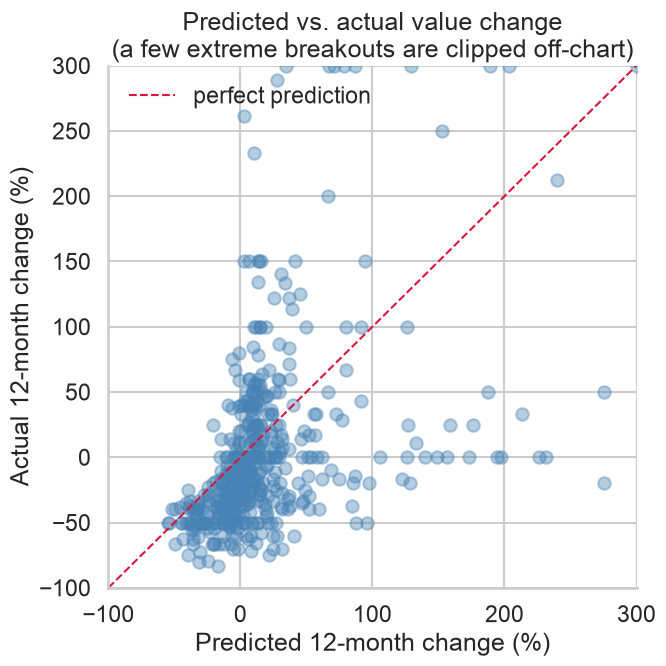

In [5]:
plot_data = backtest.copy()
plot_data["predicted_pct_change"] = plot_data["predicted_pct_change"].clip(-1, 3) * 100
plot_data["value_change_12m_pct"] = plot_data["value_change_12m_pct"].clip(-1, 3) * 100

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_data["predicted_pct_change"], plot_data["value_change_12m_pct"], alpha=0.4, color="steelblue")
lims = [-100, 300]
ax.plot(lims, lims, color="crimson", linestyle="--", linewidth=1.5, label="perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Predicted 12-month change (%)")
ax.set_ylabel("Actual 12-month change (%)")
ax.set_title("Predicted vs. actual value change\n(a few extreme breakouts are clipped off-chart)")
ax.legend(loc="upper left", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## The top 10 predicted risers, and what actually happened

In [6]:
top10 = backtest.sort_values("predicted_pct_change", ascending=False).head(10).copy()
top10["Predicted change"] = (top10["predicted_pct_change"] * 100).round(0).astype(int).map("+{}%".format)
top10["Actual change"] = (top10["value_change_12m_pct"] * 100).round(0).astype(int).map("{:+d}%".format)
top10 = top10.rename(columns={"name": "Player", "sub_position": "Position"})
top10[["Player", "Position", "Predicted change", "Actual change"]].reset_index(drop=True)

,Player,Position,Predicted change,Actual change
0,Harrison Armstrong,Central Midfield,+314%,+2300%
1,Louie Marsh,Second Striker,+276%,+50%
2,Eric da Silva Moreira,Right-Back,+275%,-20%
3,Josh Acheampong,Right-Back,+240%,+212%
4,Caleb Kporha,Right-Back,+231%,+0%
5,Tammer Bany,Centre-Forward,+226%,+0%
6,James Carragher,Centre-Back,+213%,+33%
7,Josh King,Attacking Midfield,+204%,+2400%
8,Ryan Trevitt,Central Midfield,+197%,+0%
9,Nathan Fraser,Centre-Forward,+194%,+0%


Mixed results, as the scatter plot already suggested: some of the top picks did see real, large increases (occasionally *larger* than predicted — the model tends to underestimate the size of genuine breakouts, likely because training clips extreme values to keep the squared-error fit stable), several barely moved, and one went slightly negative. The model is picking up real signal on *who* is likely to rise, but the *size* of the increase is much less reliable, and a handful of predictions simply miss.

## Caveats

- This backtest covers one rollback date (June 2025) and one horizon (12 months). A single walk-forward split is far weaker evidence than repeating this at several dates would be — that's the natural next step if this is worth trusting more.
- The 469-player sample is players who *did* get re-valued within the tolerance window; players who weren't re-valued at all in that time aren't represented here, which could bias the comparison in either direction.
- Everything this model doesn't know about — injuries, transfer speculation, contract situations, managerial changes — is exactly the kind of thing that drives the biggest surprises, which is consistent with the model's weakest spot being the *size* of breakout moves rather than *direction*.